In [43]:
import numpy as np
from scipy.stats import multivariate_normal as mvn
from sklearn.decomposition import PCA
from scipy.io import loadmat
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns




In [44]:
data = loadmat('data/data.mat')
labels = loadmat('data/label.mat')

In [45]:
print("Keys in data.mat:", data.keys())
print("Keys in label.mat:", labels.keys())

Keys in data.mat: dict_keys(['__header__', '__version__', '__globals__', 'data'])
Keys in label.mat: dict_keys(['__header__', '__version__', '__globals__', 'trueLabel'])


In [ ]:
"""Sourced/Background Research:
https://acme.byu.edu/00000186-a3db-d200-adf6-a7ff294e0001/gmm-pdf#:~:text=A%20good%20way%20to%20initialize,perform%20the%20expectation%20maximization%20algorithm
^how to pick random gaussian means
https://people.duke.edu/~ccc14/sta-663/EMAlgorithm.html
https://stackoverflow.com/questions/54464444/covariance-matrix-using-np-matmuldata-t-data
-referenced/used quite a bit of the demo code, this is noted in comments below. It was used as a framework
https://numpy.org/doc/2.1/reference/generated/numpy.logaddexp.html
https://stackoverflow.com/questions/30031920/make-numpy-sum-return-a-sum-of-matrices-instead-of-a-single-number


"""

Converged at iteration 10


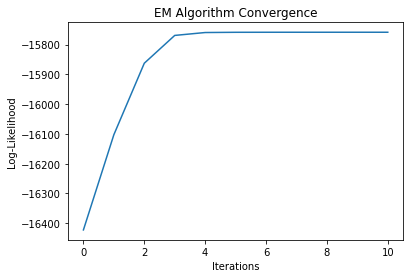

In [46]:

# Load data
data_mat = scipy.io.loadmat("data/data.mat")
label_mat = scipy.io.loadmat("data/label.mat")

# Extract and preprocess data
data = data_mat['data']
labels = label_mat['trueLabel'].flatten()

# Filter digits "2" and "6"
mask = (labels == 2) | (labels == 6)
data = data[:, mask]
labels = labels[mask]

# Apply PCA to reduce dimensionality
pca = PCA(n_components=4)
data_pca = pca.fit_transform(data.T)  # Transpose to make rows samples

# Initialize EM parameters
np.random.seed(42)
C = 2  # Number of clusters
n, d = data_pca.shape

# taken from Demo Code
# Mixing coefficients (prior probabilities) for  components
pi = np.random.random(C)  # Random initialization
pi /= np.sum(pi)  # Normalize so they sum to 1

# taken from Demo code
# Randomly initialize means for the Gaussian components
means = np.random.randn(C, d)


#taken from Demo Code
#initializing covariance matricies / means/ sigma
covariances = []
for c in range(C):
    dummy = np.random.randn(d, d)  # Random matrix
    covariances.append(dummy @ dummy.T) 

# Initialize responsibilities (posterior probabilities)
tau = np.zeros((n, C))

# EM Algorithm
log_likelihoods = []
max_iter = 100
tol = 1e-3
for iteration in range(max_iter):
    #taken from Demo Code- Estep
    
    # Compute responsibilities (tau) for each data point
    for c in range(C):
        tau[:, c] = pi[c] * mvn.pdf(data_pca, mean=means[c], cov=covariances[c])
    # Normalize responsibilities
    tau /= np.sum(tau, axis=1, keepdims=True)

    # taken from Demo Code- Mstep
    for c in range(C):
        # Update prior (pi)
        Nc = np.sum(tau[:, c])  # Total responsibility for component c
        pi[c] = Nc / n  # Fraction of data points assigned to this component
        # Update mean (mu)
        means[c] = np.sum(tau[:, c][:, np.newaxis] * data_pca, axis=0) / Nc
        # Update covariance (Sigma)
        diff = data_pca - means[c]
        #print(diff)
        covariances[c] = (diff.T @ (tau[:, c][:, np.newaxis] * diff)) / Nc
        
    #taken from demo code - calculating log likhilood
    # Compute the log-likelihood for this iteration
    likelihood_matrix = np.zeros((len(data_pca), C))  # Rows: data points, Columns: clusters

    # Populate likelihoods for each cluster
    for c in range(C):
        likelihood_matrix[:, c] = pi[c] * mvn.pdf(data_pca, mean=means[c], cov=covariances[c])

    # Sum across clusters to get the total likelihood for each data point
    total_likelihood = np.sum(likelihood_matrix, axis=1)
   # print(total_likelihood)
    # Computing and storing log liklihood
    log_likelihood = np.sum(np.log(total_likelihood))
    log_likelihoods.append(log_likelihood)

    # Check convergence
    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
        print(f"Converged at iteration {iteration}")
        break

# Plot log-likelihood convergence
plt.plot(log_likelihoods)
plt.xlabel("Iterations")
plt.ylabel("Log-Likelihood")
plt.title("EM Algorithm Convergence")
plt.show()


In [47]:
print("Final Component Weights (Mixing Coefficients):")
for c in range(C):
    print(f"Component {c+1}: {pi[c]:.4f}")


Final Component Weights (Mixing Coefficients):
Component 1: 0.4870
Component 2: 0.5130


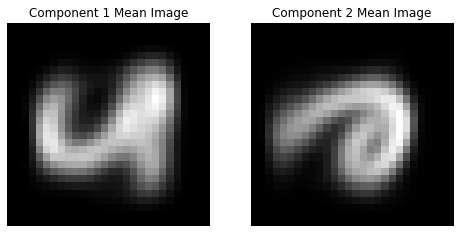

In [48]:
mean_original_space = pca.inverse_transform(means)

# Reshape and plot as 28x28 images
fig, axes = plt.subplots(1, C, figsize=(8, 4))
for c in range(C):
    image = mean_original_space[c].reshape(28, 28)  
    axes[c].imshow(image, cmap='gray')  
    axes[c].set_title(f"Component {c+1} Mean Image")
    axes[c].axis("off")

plt.show()

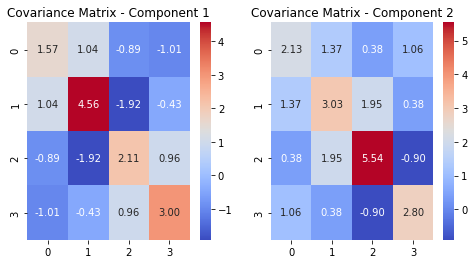

In [49]:
fig, axes = plt.subplots(1, C, figsize=(8, 4))
for c in range(C):
    sns.heatmap(covariances[c], annot=True, fmt=".2f", cmap="coolwarm", ax=axes[c])
    axes[c].set_title(f"Covariance Matrix - Component {c+1}")

plt.show()